# Electricity Consumption Prediction
In this notebook, we train a neural network to predict electricity consumption trends at different granularity levels (daily, weekly, monthly).

For more information, look up the dataset description at:  
https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014

-------
## Initialization
Here, we import necessary libraries and initialize hyperparameters for use in the entire notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

-------
## EDA
Quick look at the data to know what we're dealing with.

In [2]:
# view first few lines of the raw data
with open("LD2011_2014.txt", "r") as f:
    for _ in range(5):
        print(f.readline().rstrip())

"";"MT_001";"MT_002";"MT_003";"MT_004";"MT_005";"MT_006";"MT_007";"MT_008";"MT_009";"MT_010";"MT_011";"MT_012";"MT_013";"MT_014";"MT_015";"MT_016";"MT_017";"MT_018";"MT_019";"MT_020";"MT_021";"MT_022";"MT_023";"MT_024";"MT_025";"MT_026";"MT_027";"MT_028";"MT_029";"MT_030";"MT_031";"MT_032";"MT_033";"MT_034";"MT_035";"MT_036";"MT_037";"MT_038";"MT_039";"MT_040";"MT_041";"MT_042";"MT_043";"MT_044";"MT_045";"MT_046";"MT_047";"MT_048";"MT_049";"MT_050";"MT_051";"MT_052";"MT_053";"MT_054";"MT_055";"MT_056";"MT_057";"MT_058";"MT_059";"MT_060";"MT_061";"MT_062";"MT_063";"MT_064";"MT_065";"MT_066";"MT_067";"MT_068";"MT_069";"MT_070";"MT_071";"MT_072";"MT_073";"MT_074";"MT_075";"MT_076";"MT_077";"MT_078";"MT_079";"MT_080";"MT_081";"MT_082";"MT_083";"MT_084";"MT_085";"MT_086";"MT_087";"MT_088";"MT_089";"MT_090";"MT_091";"MT_092";"MT_093";"MT_094";"MT_095";"MT_096";"MT_097";"MT_098";"MT_099";"MT_100";"MT_101";"MT_102";"MT_103";"MT_104";"MT_105";"MT_106";"MT_107";"MT_108";"MT_109";"MT_110";"MT_111

In [3]:
# load the data
df = pd.read_csv("LD2011_2014.txt", sep=";", index_col=0, parse_dates=True, decimal=",")
df.head()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


A couple of notes here:
- Each row represents clients' consumptions in a 15-minute interval
- Each column is a different client
- Some of the clients were only added from 2012 onward. Before they existed, consumption was set as 0
- At the dataset's link, it says to divide the values by 4 to get consumption in units of kWh.

From now on, let's look at data from 2012 onward, letting the intervals be daily instead and convert energy consumption into standard kWh values.

In [4]:
# adjust data to daily frequency and convert to kWh
df = df.loc['2012':'2014']   # 2012 to 2014
df = df.resample('D').sum()  # daily frequency
df = df.div(4)               # divide by 4 to get kWh
df

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2012-01-01,177.982234,624.466572,499.782798,2846.036585,1372.256098,6170.386905,134.963256,5533.670034,1438.811189,1574.193548,...,6439.329051,701425.0,49812.236287,50522.727273,428.943937,247.220597,10291.483758,1226.627713,16519.061584,0.000000
2012-01-02,256.345178,644.025605,119.678540,3072.154472,1553.353659,5845.982143,99.067270,7051.346801,2096.590909,1389.247312,...,7684.511064,873600.0,60340.717300,61193.181818,1871.903520,563.341135,13638.059701,3538.814691,19326.063050,0.000000
2012-01-03,260.152284,719.061166,193.744570,2951.219512,1614.024390,5601.934524,91.153194,7014.309764,1949.300699,2042.204301,...,6002.676660,861250.0,57636.075949,68681.818182,1957.627119,659.742539,13883.669886,3903.171953,20083.027859,0.000000
2012-01-04,273.477157,627.489331,342.311034,2924.288618,1663.109756,5698.660714,92.990390,6831.649832,1944.930070,1770.161290,...,7186.652391,855250.0,61664.556962,68431.818182,1877.118644,546.518432,13307.506585,3589.315526,19157.624633,0.000000
2012-01-05,337.880711,660.206259,991.311903,2923.272358,1596.036585,5302.083333,82.815150,6597.643098,1966.346154,1930.107527,...,6597.787295,869650.0,58469.409283,65096.590909,1838.005215,614.686951,14112.598771,4696.160267,19960.777126,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-27,52.982234,536.450925,44.309296,3736.280488,1842.073171,5531.994048,126.059921,7187.710438,1491.695804,1404.569892,...,7064.239829,788950.0,54845.991561,65227.272727,2109.843546,174.517262,13370.280948,1955.759599,17742.118768,359716.216216
2014-12-28,56.789340,532.894737,37.793223,3581.808943,1694.207317,5030.505952,107.405314,6313.973064,1279.720280,1198.655914,...,7203.783012,818025.0,55180.379747,64369.318182,2042.372881,138.092452,11478.709394,1101.419032,16533.907625,388297.297297
2014-12-29,62.182741,553.165007,40.182450,3516.768293,1799.695122,5706.101190,137.648389,7571.548822,1674.388112,1584.408602,...,7206.281228,777275.0,51713.080169,67272.727273,2109.517601,288.472791,13482.221247,3228.714524,18470.674487,451621.621622
2014-12-30,58.058376,551.386913,41.268462,3572.662602,1797.256098,5970.238095,146.693047,7727.272727,1621.940559,1622.311828,...,7122.055675,726075.0,51031.645570,65903.409091,2653.846154,223.083675,14083.625988,3999.165275,18487.536657,466891.891892


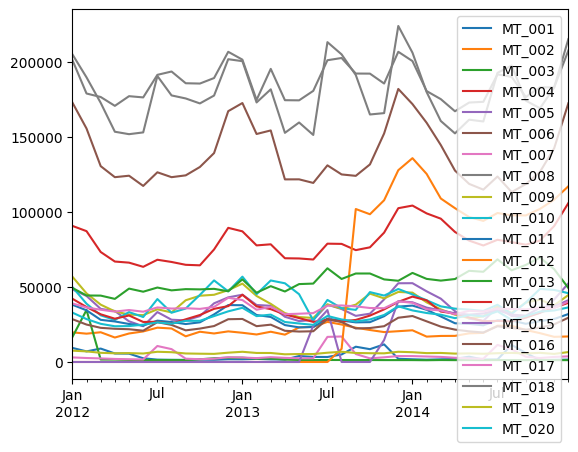

In [5]:
# plot the first 20 clients' MONTHLY consumptions
df.iloc[:, :20].resample('ME').sum().plot()
plt.show()

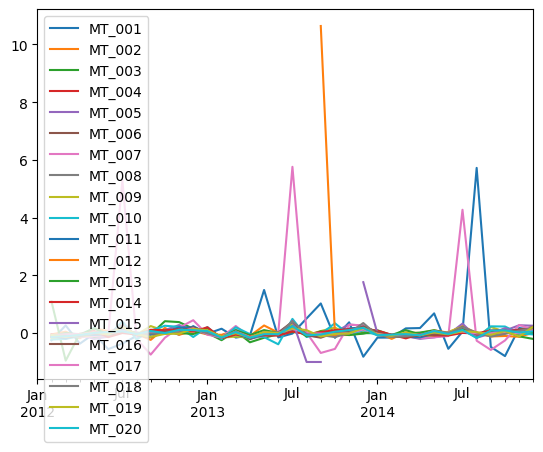

In [6]:
# plot the first 20 clients' MONTHLY percent changes in consumptions
df.iloc[:, :20].resample('ME').sum().pct_change().plot()
plt.show()

Some wierd lines in the above image. This is probably the result of some missing values in the time series. Let's convert these zeros into NAs and fill them back in with interpolation.

In [7]:
# convert zeros in the data to NaN, then interpolate the missing values
df = df.replace(0, np.nan)
df = df.interpolate()

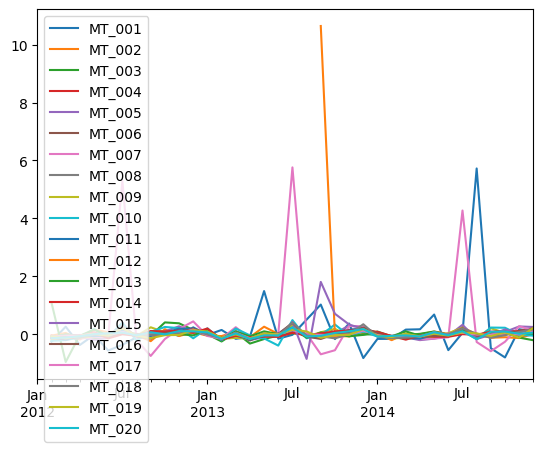

In [8]:
# AGAIN: plot the first 20 clients' MONTHLY percent changes in consumptions
df.iloc[:, :20].resample('ME').sum().pct_change().plot()
plt.show()

What's up with the orange line? Let's have a closer look!

There are two orange lines belong to clients: MT_002 & MT_012

The issue seems to be in Sep to Oct 2013.

In [9]:
df.loc[:, ['MT_002', 'MT_012']]

,MT_002,MT_012
2012-01-01,624.466572,NaN
2012-01-02,644.025605,NaN
2012-01-03,719.061166,NaN
2012-01-04,627.489331,NaN
2012-01-05,660.206259,NaN
...,...,...
2014-12-27,536.450925,3875.531915
2014-12-28,532.894737,3158.510638
2014-12-29,553.165007,4302.659574
2014-12-30,551.386913,4326.595745


In [10]:
df.loc[:, ['MT_002', 'MT_012']].asfreq('ME')

,MT_002,MT_012
2012-01-31,627.133713,NaN
2012-02-29,661.628734,NaN
2012-03-31,614.687055,NaN
2012-04-30,372.688478,NaN
2012-05-31,620.910384,NaN
2012-06-30,753.733997,NaN
2012-07-31,762.268848,NaN
2012-08-31,551.920341,NaN
2012-09-30,695.768137,NaN
2012-10-31,622.155050,NaN


It seems that MT_012 hasn't gone active till August of 2013, so interpolation did not fill those early zeros.

It's settled then. Remove all clients who still have some zeros in them and plot for the third time!

In [11]:
# remove clients that still have ANY nans in their consumption data even after interpolation
print('df.shape before removing clients with nans:', df.shape)
df = df.loc[:, df.notnull().all(axis=0)]
print('df.shape after removing clients with nans:', df.shape)

df.shape before removing clients with nans: (1096, 370)
df.shape after removing clients with nans: (1096, 320)


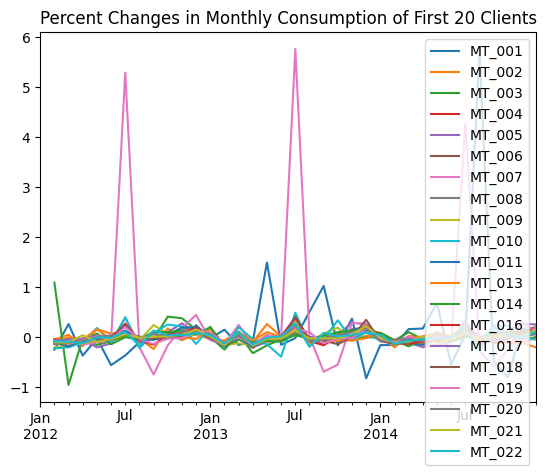

In [12]:
# YET AGAIN: plot the first 20 clients' MONTHLY percent changes in consumptions
df.iloc[:, :20].resample('ME').sum().pct_change().plot(title='Percent Changes in Monthly Consumption of First 20 Clients')
plt.show()

***Now*** we're ready to build some forecasting models!

Moving on...

-------
# Helper Functions

-------
# Training Functions

-------
# Train & Evaluate